VP Wavelet Comparison

  Note: VP wavelet sigma=0 by construction (rank-1 kernel).
  Used as topological (ECC) reference only.

  Kernel 3503 (Most Robust)
    sigma=0.978563  L2=29.5466  Wasserstein=0.7938
  Kernel 2905 (Most Vulnerable)
    sigma=2.90e-07  L2=29.7658  Wasserstein=12.0973


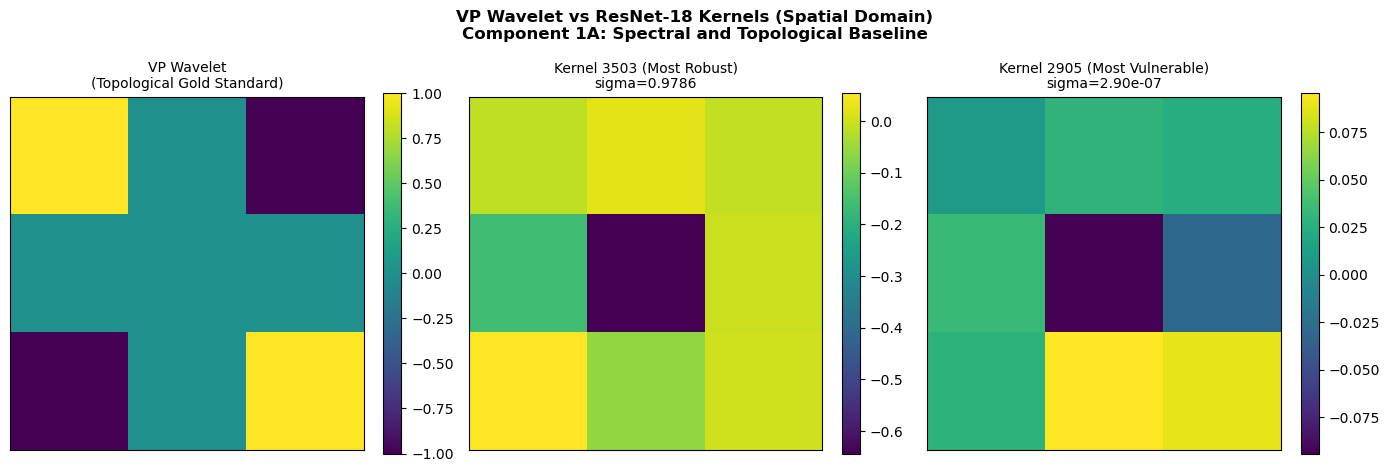

Saved: VPSpatialComparison.png


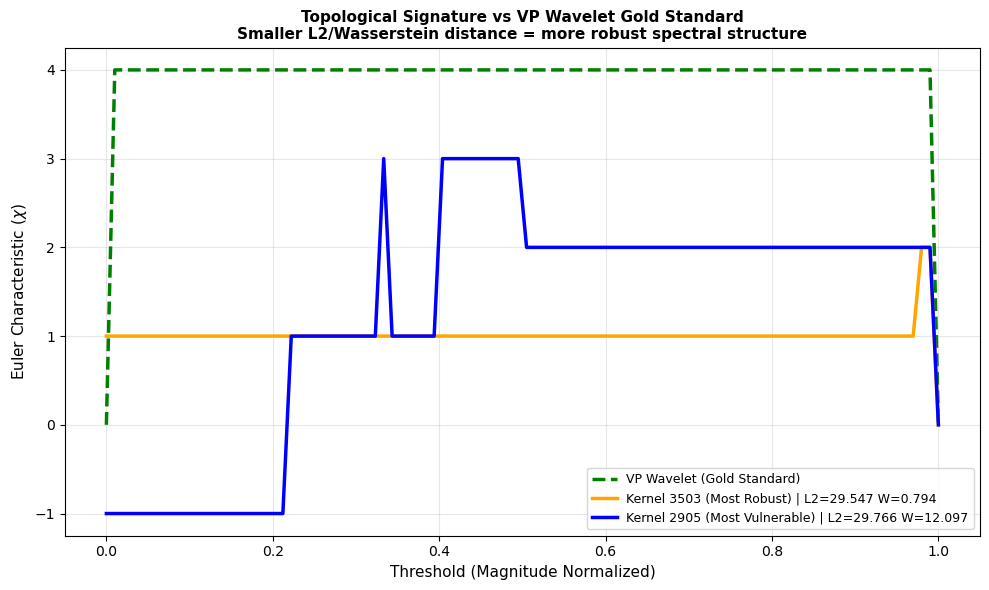

Saved: VPECCComparison.png

Computing L2 distances for all 4096 kernels...
  500/4096 done
  1000/4096 done
  1500/4096 done
  2000/4096 done
  2500/4096 done
  3000/4096 done
  3500/4096 done
  4000/4096 done


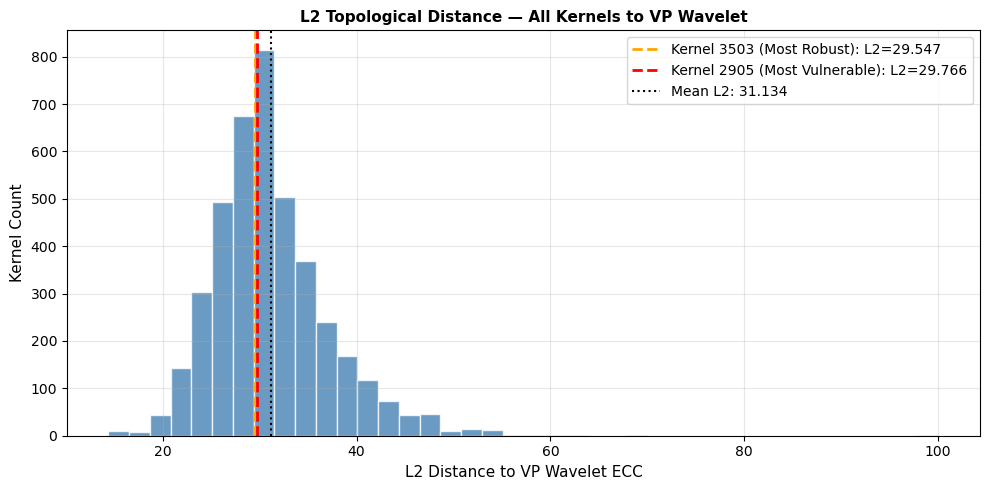

Saved: VPDistanceDistribution.png

  Mean L2:                   31.1341
  Kernel 3503 L2:       29.5466
  Kernel 2905 L2:   29.7658


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              calculateEcc, eccL2Distance, eccWassersteinDistance,
                              generateVPWaveletKernel,
                              IDXROBUST, IDXVULNERABLE, CSVPATH)

# ============================================================
# Load kernels
# ============================================================
kernels = loadKernels(CSVPATH)

# ============================================================
# Compute magnitude responses and ECCs
# ============================================================
vp     = generateVPWaveletKernel()
magVp  = computeMagnitudeResponse(vp)
magRob = computeMagnitudeResponse(kernels[IDXROBUST])
magVul = computeMagnitudeResponse(kernels[IDXVULNERABLE])

t,  eccVp  = calculateEcc(magVp)
_,  eccRob = calculateEcc(magRob)
_,  eccVul = calculateEcc(magVul)

dL2Rob = eccL2Distance(eccRob, eccVp)
dL2Vul = eccL2Distance(eccVul, eccVp)
dWRob  = eccWassersteinDistance(eccRob, eccVp)
dWVul  = eccWassersteinDistance(eccVul, eccVp)

sigmaRob = computeSigma(kernels[IDXROBUST])
sigmaVul = computeSigma(kernels[IDXVULNERABLE])

print("="*60)
print("VP Wavelet Comparison")
print("="*60)
print(f"\n  Note: VP wavelet sigma=0 by construction (rank-1 kernel).")
print(f"  Used as topological (ECC) reference only.\n")
print(f"  Kernel {IDXROBUST} (Most Robust)")
print(f"    sigma={sigmaRob:.6f}  L2={dL2Rob:.4f}  Wasserstein={dWRob:.4f}")
print(f"  Kernel {IDXVULNERABLE} (Most Vulnerable)")
print(f"    sigma={sigmaVul:.2e}  L2={dL2Vul:.4f}  Wasserstein={dWVul:.4f}")

# ============================================================
# Figure 1: Spatial domain comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("VP Wavelet vs ResNet-18 Kernels (Spatial Domain)\n"
             "Component 1A: Spectral and Topological Baseline",
             fontsize=12, fontweight='bold')

plotData = [
    (vp,                   "VP Wavelet\n(Topological Gold Standard)"),
    (kernels[IDXROBUST],   f"Kernel {IDXROBUST} (Most Robust)\n"
                           f"sigma={sigmaRob:.4f}"),
    (kernels[IDXVULNERABLE], f"Kernel {IDXVULNERABLE} (Most Vulnerable)\n"
                             f"sigma={sigmaVul:.2e}"),
]
for ax, (k, title) in zip(axes, plotData):
    im = ax.imshow(k, cmap='viridis')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("VPSpatialComparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: VPSpatialComparison.png")

# ============================================================
# Figure 2: ECC curve comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, eccVp,  color='green',  linewidth=2.5, linestyle='--',
        label='VP Wavelet (Gold Standard)')
ax.plot(t, eccRob, color='orange', linewidth=2.5,
        label=f'Kernel {IDXROBUST} (Most Robust) | '
              f'L2={dL2Rob:.3f} W={dWRob:.3f}')
ax.plot(t, eccVul, color='blue',   linewidth=2.5,
        label=f'Kernel {IDXVULNERABLE} (Most Vulnerable) | '
              f'L2={dL2Vul:.3f} W={dWVul:.3f}')
ax.set_title("Topological Signature vs VP Wavelet Gold Standard\n"
             "Smaller L2/Wasserstein distance = more robust spectral structure",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Threshold (Magnitude Normalized)", fontsize=11)
ax.set_ylabel("Euler Characteristic ($\\chi$)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("VPECCComparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: VPECCComparison.png")

# ============================================================
# Figure 3: Full population L2 distance distribution
# ============================================================
print("\nComputing L2 distances for all 4096 kernels...")
allL2 = []
for i, h in enumerate(kernels):
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    allL2.append(eccL2Distance(ecc, eccVp))
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/4096 done")
allL2 = np.array(allL2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(allL2, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(allL2[IDXROBUST], color='orange', linewidth=2, linestyle='--',
           label=f'Kernel {IDXROBUST} (Most Robust): L2={allL2[IDXROBUST]:.3f}')
ax.axvline(allL2[IDXVULNERABLE], color='red', linewidth=2, linestyle='--',
           label=f'Kernel {IDXVULNERABLE} (Most Vulnerable): L2={allL2[IDXVULNERABLE]:.3f}')
ax.axvline(np.mean(allL2), color='black', linewidth=1.5, linestyle=':',
           label=f'Mean L2: {np.mean(allL2):.3f}')
ax.set_title("L2 Topological Distance — All Kernels to VP Wavelet",
             fontsize=11, fontweight='bold')
ax.set_xlabel("L2 Distance to VP Wavelet ECC", fontsize=11)
ax.set_ylabel("Kernel Count", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("VPDistanceDistribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: VPDistanceDistribution.png")
print(f"\n  Mean L2:                   {np.mean(allL2):.4f}")
print(f"  Kernel {IDXROBUST} L2:       {allL2[IDXROBUST]:.4f}")
print(f"  Kernel {IDXVULNERABLE} L2:   {allL2[IDXVULNERABLE]:.4f}")